# Scaling Ambiguity Augmenting Human Annotation in Speech Emotion Recognition with Audio-Language Models - Saturation Analysis

Saturation analysis for synthetic annotation count (**Section 4.1**, **Figure 2**).

This notebook addresses the question: how many synthetic annotations are needed before the resulting approximated distribution converges toward the empirical distribution? We sweep annotator counts from 1 to 20, measure JS divergence between synthetic and human distributions at each count, and fit a saturation curve to identify the convergence point.

## Outputs
-------
- fig2a.pdf : JS Divergence vs. annotation count for IEMOCAP
- fig2b.pdf : JS Divergence vs. annotation count for MSP-Podcast

## Dependencies Import

In [ ]:
import sys
sys.path.append('..')

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import Counter
from scipy.optimize import curve_fit
from IPython.display import display, HTML

from lib import load_data as ld
from lib import evaluation_lib as ev

In [ ]:
# Set paths
IEMOCAP_RAW_SYNTHETIC_PATH = "../processed_data/annotations_evaluation/gemini25Pro_iemocap_raw_annotations_20.json"
MSP_RAW_SYNTHETIC_PATH = "../processed_data/annotations_evaluation/gemini_msp_raw_annotations_20.json"
HUMAN_IEMOCAP_RAW_ANNOTATIONS_PATH = "../processed_data/human_iemocap_train_raw_annotations.json"
HUMAN_MSP_RAW_ANNOTATIONS_PATH = "../processed_data/human_msp_train_raw_annotations.json"

In [ ]:
# Load raw annotations
with open(IEMOCAP_RAW_SYNTHETIC_PATH, 'r') as f:
    iemocap_raw_synthetic = json.load(f)
print(f"Loaded {len(iemocap_raw_synthetic)} samples with IEMOCAP raw annotations")

with open(MSP_RAW_SYNTHETIC_PATH, 'r') as f:
    msp_raw_synthetic = json.load(f)
print(f"Loaded {len(msp_raw_synthetic)} samples with MSP raw annotations")

# Load human annotations for comparison
iemocap_human_annotations = ld.load_train_distributions('iemocap')
msp_human_annotations = ld.load_train_distributions('msp')

## Section 1: Finding the Appropriate Synthetic Annotator Number

In [ ]:
def sample_annotators(raw_annotations, num_annotators, emotion_list,random_seed=42):
    
    """
    Sample a subset of annotators for each audio sample and create a new distribution.
    
    Args:
        raw_annotations: Dictionary of audio samples with raw annotations
        num_annotators: Number of annotators to sample (must be less than or equal to available annotators)
        random_seed: Random seed for reproducibility
        
    Returns:
        List of distribution objects in the format expected by evaluation functions
    """
    
    random.seed(random_seed)
    sampled_distributions = []
    
    for audio_id, annotations in raw_annotations.items():
        # Ensure we don't try to sample more annotators than available
        actual_sample_size = min(num_annotators, len(annotations))
        
        # Sample annotators without replacement
        sampled_annotations = random.sample(annotations, actual_sample_size)
        
        # Count emotions
        emotion_counter = Counter([anno["emotion"] for anno in sampled_annotations])
        
        # Create distribution
        emotion_distribution = {}
        for emotion in emotion_list:
            emotion_distribution[emotion] = emotion_counter.get(emotion, 0) / actual_sample_size
        
        # Create distribution object
        distribution = {
            "id": audio_id,
            "emotion": emotion_distribution,
            "num_annotators": actual_sample_size
        }
        
        sampled_distributions.append(distribution)
    
    return sampled_distributions

In [ ]:
def evaluate_annotator_count(raw_annotations, human_annotations,
                             annotator_counts, emotion_list, num_runs=5):
    """
    Sweep over annotator counts and evaluate JS divergence against human
    distributions. Each count is evaluated with multiple random seeds to
    estimate variance caused by annotator selection.
 
    Parameters
    ----------
    raw_annotations : dict
        Raw synthetic annotations keyed by audio ID.
    human_annotations : list of dict
        Human-derived distributions, each with an "id" field for matching.
    annotator_counts : list of int
        Counts to evaluate (e.g. list(range(1, 21))).
    emotion_list : list of str
        Emotion categories used by the dataset.
    num_runs : int
        Number of independent random samples per count for variance estimation.
 
    Returns
    -------
    pd.DataFrame
        Columns: annotator_count, run, js_divergence, bhattacharyya_coef,
        sample_count.
    """
    # Index human annotations by ID for O(1) lookup during matching
    human_dict = {item["id"]: item for item in human_annotations}
 
    results = []
 
    for count in tqdm(annotator_counts, desc="Annotator counts"):
        for run in range(num_runs):
            # Sample synthetic distributions with a unique seed per run
            sampled_distributions = sample_annotators(
                raw_annotations, count, emotion_list, random_seed=42 + run
            )
 
            # Keep only samples that have a matching human annotation
            matched_sampled = [d for d in sampled_distributions if d["id"] in human_dict]
            matched_human   = [human_dict[d["id"]] for d in matched_sampled]
 
            sampled_emotions = [item["emotion"] for item in matched_sampled]
            human_emotions   = [item["emotion"] for item in matched_human]
 
            eval_results = ev.evaluate_distributions(sampled_emotions, human_emotions, emotion_list)
 
            js_mean = eval_results["distribution_metrics"]["jensen_shannon_divergence"]["mean"]
            bc_mean = eval_results["distribution_metrics"]["bhattacharyya_coefficient"]["mean"]
 
            results.append({
                "annotator_count":   count,
                "run":               run,
                "js_divergence":     js_mean,
                "bhattacharyya_coef": bc_mean,
                "sample_count":      len(matched_sampled)
            })
 
    return pd.DataFrame(results)

In [ ]:
# Define annotator counts to evaluate, from 1 to 20
annotator_counts = list(range(1, 21))

# Run evaluation with 5 random runs for each count, each time with a different annotator subset. Then average the results.
iemocap_results_df = evaluate_annotator_count(iemocap_raw_synthetic, iemocap_human_annotations, annotator_counts, ev.IEMOCAP_EMOTIONS, num_runs=5)

msp_results_df = evaluate_annotator_count(msp_raw_synthetic, msp_human_annotations, annotator_counts, ev.MSP_EMOTIONS, num_runs=5)

In [ ]:
def summarise_results(results_df):
    """
    Aggregate per-run results by annotator count, reporting mean and std
    for each metric across the multiple random runs.
 
    Parameters
    ----------
    results_df : pd.DataFrame
        Output of evaluate_annotator_count().
 
    Returns
    -------
    pd.DataFrame
        Mean and std of JS divergence and Bhattacharyya coefficient per count.
    """
    summary = results_df.groupby('annotator_count').agg({
        'js_divergence':      ['mean', 'std'],
        'bhattacharyya_coef': ['mean', 'std'],
        'sample_count':       'mean'
    }).reset_index()
 
    # Flatten MultiIndex columns (e.g. ('js_divergence', 'mean') -> 'js_divergence_mean')
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.values]
 
    return summary

In [ ]:
iemocap_summary = summarise_results(iemocap_results_df)
msp_summary     = summarise_results(msp_results_df)
 
display(HTML("<h3>IEMOCAP Dataset</h3>"))
display(iemocap_summary)
 
display(HTML("<h3>MSP-Podcast Dataset</h3>"))
display(msp_summary)

## Section 2: Figure Generation

In [17]:
def fit_and_plot_curve(x_data, y_data, lower_is_better=False):
    """
    Helper function to fit saturation curve and find saturation point
    
    Returns:
        tuple: (x_curve, y_curve, saturation_x) for plotting, or (None, None, None) if fitting fails
    """
    def saturation_curve(x, a, b, c):
        return a - b * np.exp(-c * x)
    
    # Handle case where lower is better (invert for curve fitting)
    if lower_is_better:
        y_data_fit = max(y_data) - y_data
    else:
        y_data_fit = y_data

    try:
        params, _ = curve_fit(saturation_curve, x_data, y_data_fit, maxfev=10000)

        # Generate points for the curve
        x_curve = np.linspace(min(x_data), max(x_data), 100)
        y_curve_fit = saturation_curve(x_curve, *params)

        # Convert back if we inverted
        if lower_is_better:
            y_curve = max(y_data) - y_curve_fit
        else:
            y_curve = y_curve_fit

        # Find saturation point differently based on whether lower or higher is better
        asymptotic_value = params[0]  # This is the asymptotic value for the FITTED data

        saturation_x = None
        if lower_is_better:
            min_value = max(y_data) - asymptotic_value
            # Calculate the threshold that's 10% above the minimum value
            threshold = min_value + 0.1 * (max(y_data) - min_value)

            for i, val in enumerate(y_curve):
                if val <= threshold:
                    saturation_x = x_curve[i]
                    break
        else:
            # For "higher is better" metrics:
            # Find where we reach 95% of the asymptotic value
            threshold = 0.95 * asymptotic_value

            # When working with the original scale
            for i, val in enumerate(y_curve_fit):
                if val >= threshold:
                    saturation_x = x_curve[i]
                    break
        
        print(f"Asymptotic value: {asymptotic_value}")
        print(f"Threshold: {threshold}")
        print(f"First few y_curve values: {y_curve[:5]}")
        print(f"First few x_curve values: {x_curve[:5]}")
    
        return x_curve, y_curve, saturation_x

    except Exception as e:
        print(f"Curve fitting failed: {e}")
        return None, None, None


def plot_iemocap_metric_curve(iemocap_summary, metric_col, metric_std_col, ylabel, lower_is_better=False, show_saturation_line=False, figsize=(4, 3)):
    """
    Plot IEMOCAP metric curve with fitted saturation curve
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot data points with error bars
    plt.errorbar(iemocap_summary['annotator_count'], iemocap_summary[metric_col], 
                 yerr=iemocap_summary[metric_std_col], fmt='o-', capsize=5)

    # Fit and plot curve
    x_data = iemocap_summary['annotator_count']
    y_data = iemocap_summary[metric_col]
    
    x_curve, y_curve, saturation_x = fit_and_plot_curve(x_data, y_data, lower_is_better)
    
    if x_curve is not None:
        plt.plot(x_curve, y_curve, 'r--', label='Fitted Curve')
        
        if show_saturation_line and saturation_x is not None:
            plt.axvline(x=saturation_x, color='g', linestyle='--', 
                      label=f'Saturation: ~{int(round(saturation_x))}')
    
    # Styling
    plt.xlabel('Number of Annotations', fontsize=13, fontweight='bold')
    plt.ylabel(ylabel, fontsize=13, fontweight='bold')
    plt.xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20], fontsize=13)
    plt.yticks(fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper right')
    
    plt.tight_layout()
    plt.subplots_adjust()
    
    plt.savefig(f'fig2a.pdf', 
        format='pdf', 
        dpi=600, 
        bbox_inches='tight',
        facecolor='white')
    
    plt.show()


def plot_msp_metric_curve(msp_summary, metric_col, metric_std_col, ylabel, lower_is_better=False, show_saturation_line=False, figsize=(4, 3)):
    """
    Plot MSP metric curve with fitted saturation curve
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot data points with error bars
    plt.errorbar(msp_summary['annotator_count'], msp_summary[metric_col], 
                 yerr=msp_summary[metric_std_col], fmt='o-', capsize=5)
    
    # Fit and plot curve
    x_data = msp_summary['annotator_count']
    y_data = msp_summary[metric_col]
    
    x_curve, y_curve, saturation_x = fit_and_plot_curve(x_data, y_data, lower_is_better)
    
    if x_curve is not None:
        plt.plot(x_curve, y_curve, 'r--', label='Fitted Curve')
        
        if show_saturation_line and saturation_x is not None:
            plt.axvline(x=saturation_x, color='g', linestyle='--', 
                      label=f'Saturation: ~{int(round(saturation_x))}')
    
    # Styling
    plt.xlabel('Number of Annotations', fontsize=13, fontweight='bold')
    plt.xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20], fontsize=13)
    plt.yticks(fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.legend(prop={'size': 12, 'weight': 'bold'}, loc='upper right')
    
    plt.tight_layout()
    
    plt.savefig(f'fig2b.pdf', 
            format='pdf', 
            dpi=600, 
            bbox_inches='tight',
            facecolor='white')
        
    plt.show()


Asymptotic value: 0.05998179514659098
Threshold: 0.36837464295370886
First few y_curve values: [0.42069632 0.41555131 0.41086019 0.40658292 0.402683  ]
First few x_curve values: [1.         1.19191919 1.38383838 1.57575758 1.76767677]


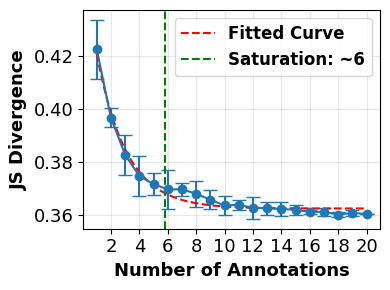

Asymptotic value: 0.02944631687292181
Threshold: 0.3577750302610098
First few y_curve values: [0.3816944  0.38045658 0.3792758  0.37814942 0.37707495]
First few x_curve values: [1.         1.19191919 1.38383838 1.57575758 1.76767677]


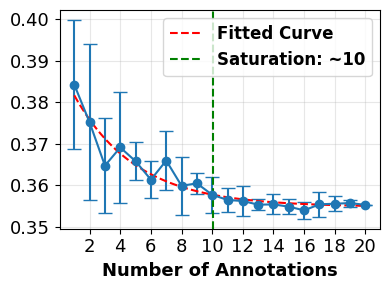

In [18]:
plot_iemocap_metric_curve(iemocap_summary, 'js_divergence_mean', 'js_divergence_std', 'JS Divergence', lower_is_better=True, show_saturation_line=True)
plot_msp_metric_curve(msp_summary, 'js_divergence_mean', 'js_divergence_std', 'JS Divergence', lower_is_better=True, show_saturation_line=True)